***Load & Inspect***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("/content/netflix_titles.csv")

In [4]:
df.head()
df.shape


(8807, 12)

In [5]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [6]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df.duplicated().any()

np.False_

***Data Cleaning***


In [8]:
df.dropna(subset=['duration'],inplace=True)


Since the 'duration' column contains null values and cannot be reasonably filled with a specific value, and given that dropping these rows will result in a data loss of less than 5%, we have decided to remove them.

In [9]:
df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Not Specified")
df["cast"] = df["cast"].fillna("Unknown")


If we were to drop rows based on null values in these columns, we would lose a significant amount of data. Therefore, instead of dropping them, we have specified 'Unknown' or 'Not Specified' for these unknown values.

In [10]:
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

Since this column contains textual data, we have filled its missing values with the mode (most frequent value).

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

The `date_added` column was converted from its object data type to datetime format to facilitate time-based analysis. Subsequently, additional features, such as the year and month, can be extracted from this column.

In [12]:
df.dropna(subset=['date_added'],inplace=True)


Since the 'date_added' column contains null values.Given that dropping these rows will result in a data loss of less than 5%, we have decided to remove them.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8706 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8706 non-null   object        
 1   type          8706 non-null   object        
 2   title         8706 non-null   object        
 3   director      8706 non-null   object        
 4   cast          8706 non-null   object        
 5   country       8706 non-null   object        
 6   date_added    8706 non-null   datetime64[ns]
 7   release_year  8706 non-null   int64         
 8   rating        8706 non-null   object        
 9   duration      8706 non-null   object        
 10  listed_in     8706 non-null   object        
 11  description   8706 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 884.2+ KB


***Exploratory Data Analysis***

In [15]:
countries=df["country"]
countries=countries.str.split(",")
countries = countries.explode()
countries = countries.str.strip()
top_8_country=countries.value_counts().head(8)


In [16]:
top_8_country

,count
country,
United States,3640
India,1045
Unknown,827
United Kingdom,787
Canada,432
France,389
Japan,314
Spain,228


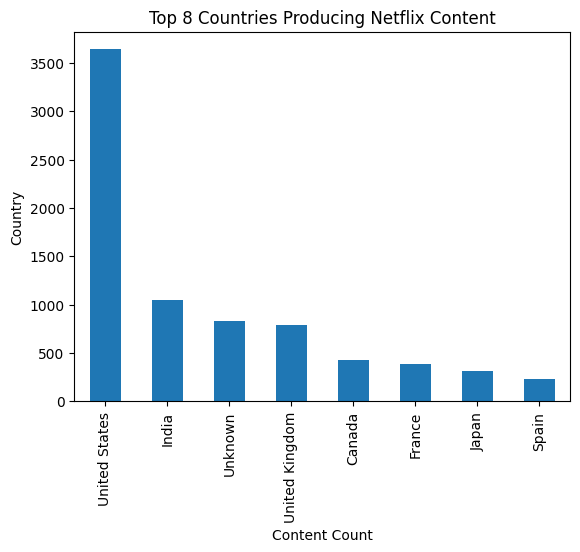

In [17]:
top_8_country.plot(kind="bar")
plt.title("Top 8 Countries Producing Netflix Content")
plt.xlabel("Content Count")
plt.ylabel("Country")
plt.show()


The bar chart clearly demonstrates that the United States is the leading country in producing content for Netflix, with a significantly higher count than other top countries.

In [18]:

date_added=df["date_added"]
df["year"]=date_added.dt.year
year_count=df["year"].value_counts()
top_5_yr_prod=year_count.head(5)
top_5_yr_prod

,count
year,
2019,1999
2020,1878
2018,1625
2021,1498
2017,1163


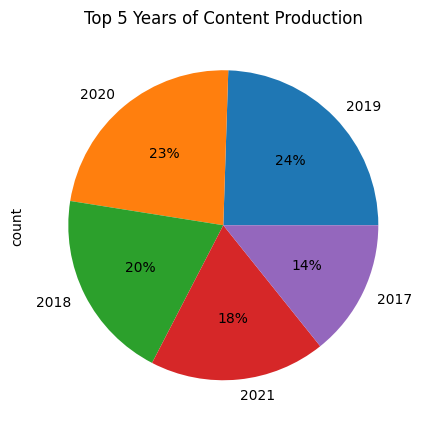

In [19]:
top_5_yr_prod.plot(kind="pie", autopct="%1.0f%%", figsize=(5,8))
plt.title("Top 5 Years of Content Production")
plt.show()

 Insight:The pie chart highlights that the years 2019, 2020, 2018, 2021, and 2017 were the most significant for Netflix content production. Notably, 2019 and 2020 were the peak years, indicating a substantial surge in content added during this period.

In [20]:
genre_df = df[['year', 'listed_in']].copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
genere_group=genre_df.groupby(['year', 'listed_in']).size().reset_index(name='count')
genere_group = genere_group.sort_values(by=['count'], ascending=False)
print(genere_group)

     year             listed_in  count
174  2018  International Movies    668
216  2019  International Movies    610
258  2020  International Movies    575
212  2019                Dramas    564
254  2020                Dramas    535
..    ...                   ...    ...
31   2013          TV Thrillers      1
32   2014    Action & Adventure      1
29   2013          TV Mysteries      1
30   2013   TV Sci-Fi & Fantasy      1
0    2008                Dramas      1

[326 rows x 3 columns]


The `genere_group` DataFrame reveals the yearly distribution of content across different genres. 'International Movies' and 'Dramas' consistently appear among the top produced genres, especially in years like 2018, 2019, and 2020, indicating their high popularity and production volume on Netflix during this period.

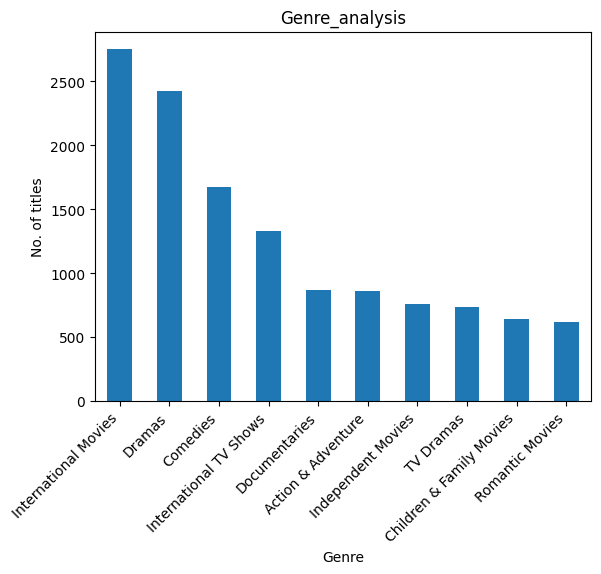

In [21]:
genre=df["listed_in"]
genre=genre.str.split(",")
genre=genre.explode()
genre=genre.str.strip()
top_genre=genre.value_counts().head(10)

top_genre.plot(kind="bar")
plt.title("Genre_analysis")
plt.xlabel("Genre")
plt.ylabel("No. of titles")
plt.xticks(rotation=45, ha='right')
plt.show()

Insight:The graph of the top 10 genres reveals that 'International Movies', 'Dramas', and 'Comedies' are the most prominent categories on Netflix. This suggests a significant focus on these genres in Netflix's content strategy and a high demand for them among its audience.

In [22]:
top_5_genre_names = top_genre.head(5).index.tolist()

average_titles_per_year_top_5 = genere_group[genere_group['listed_in'].isin(top_5_genre_names)].groupby('listed_in')['count'].mean().reset_index()

print("Average number of titles per year for the top 5 genres:")
display(average_titles_per_year_top_5)

Average number of titles per year for the top 5 genres:


,listed_in,count
0,Comedies,167.4
1,Documentaries,86.9
2,Dramas,242.7
3,International Movies,275.2
4,International TV Shows,166.0


Insight:The analysis of the average number of titles per year for the top 5 genres reveals that 'International Movies' has the highest average annual production, followed by 'Dramas' and 'Comedies'. 'International TV Shows' and 'Documentaries' also show significant average yearly contributions, indicating a consistent output in these popular categories.

In [27]:
import seaborn as sns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=month_order)



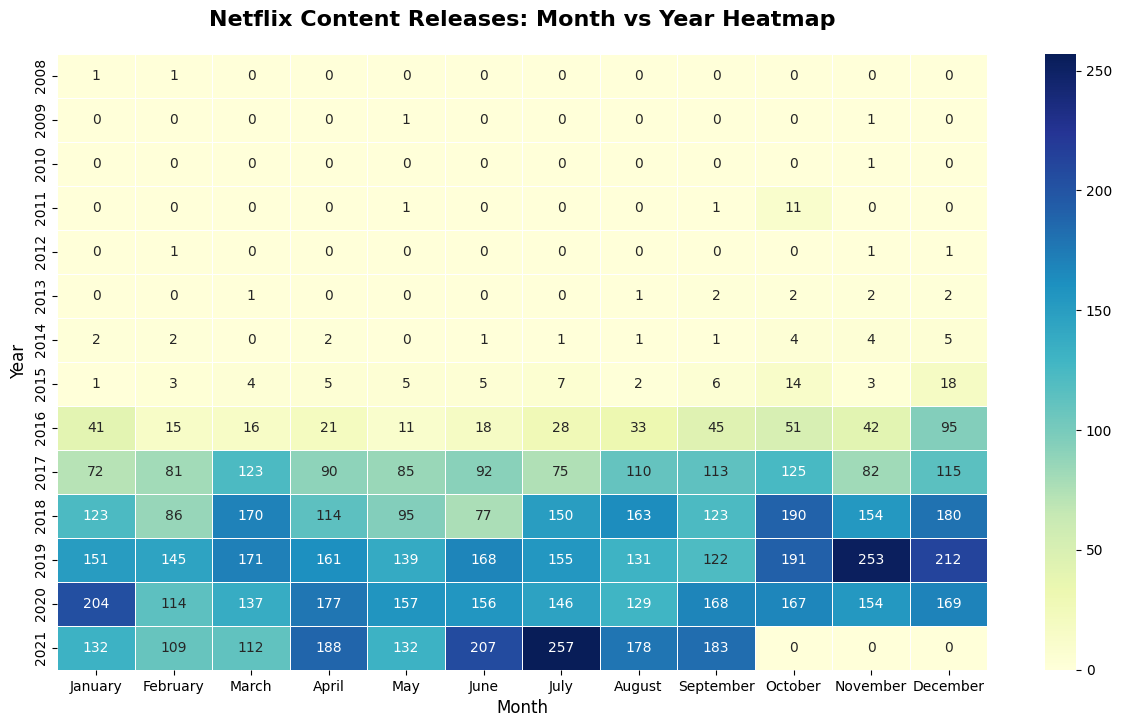

In [28]:

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)

plt.title('Netflix Content Releases: Month vs Year Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

plt.show()

Insight:It shows that certain months towards the end of the year (October, November, December), tend to have a higher volume of new content releases. This could indicate a strategic release schedule by Netflix to capture viewership during holiday seasons or end-of-year viewing trends. Additionally, we can observe the growth in content releases over the years, with a general increase in activity from earlier years to more recent ones.

In [29]:
trend_data = df[df['year_added'] >= 2008].groupby(['year_added', 'type']).size().reset_index(name='count')




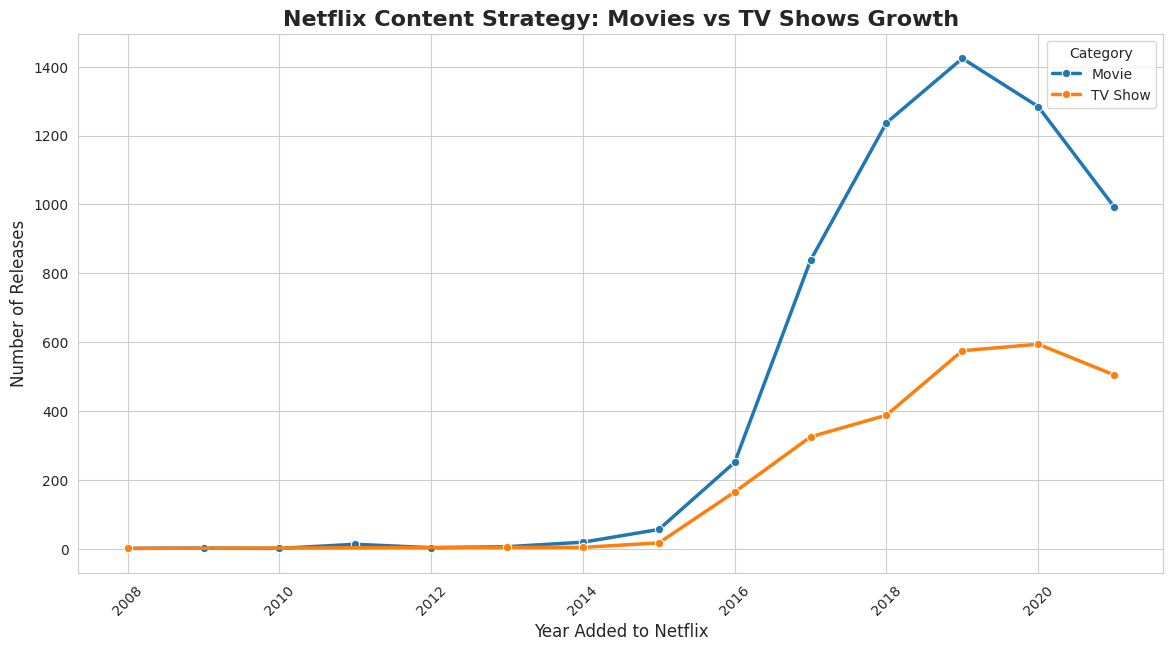

In [30]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.lineplot(data=trend_data, x='year_added', y='count', hue='type', marker='o', linewidth=2.5)

plt.title('Netflix Content Strategy: Movies vs TV Shows Growth', fontsize=16, fontweight='bold')
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')

Insight:The line plot clearly shows that while both movies and TV shows have grown significantly, movies consistently have a higher number of releases each year compared to TV shows. This indicates that despite the strong growth in TV shows, Netflix continues to add more movie titles to its library.

In [36]:
most_rating=df["rating"].value_counts()
most_rating


,count
rating,
TV-MA,3187
TV-14,2133
TV-PG,838
R,799
PG-13,490
TV-Y7,330
TV-Y,300
PG,287
TV-G,212


Text(0, 0.5, 'No. of rating')

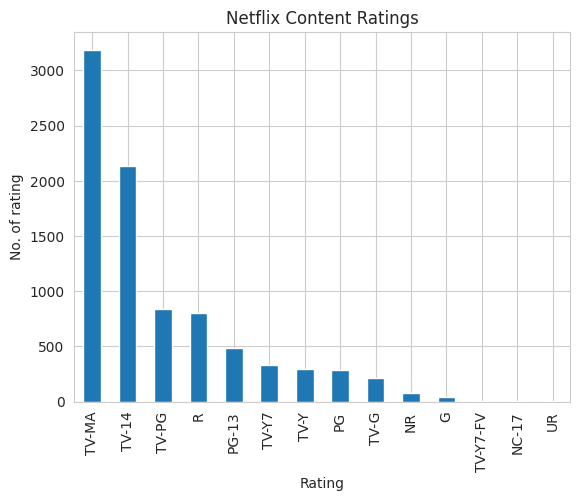

In [35]:
most_rating.plot(kind="bar")
plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("No. of rating")

Insight:It clearly shows that 'TV-MA' is the most frequent rating, indicating that a significant portion of Netflix's content is aimed at mature audiences.

Text(0, 0.5, 'Duration')

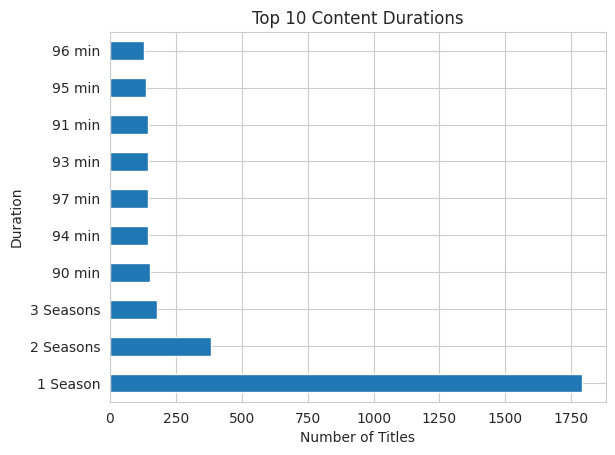

In [41]:
duration=df["duration"]

top_duration=duration.value_counts().head(10)
top_duration.plot(kind="barh")
plt.title("Top 10 Content Durations")
plt.xlabel("Number of Titles")
plt.ylabel("Duration")

Insight:The horizontal bar chart clearly illustrates the distribution of content durations on Netflix. It reveals that '1 Season' is by far the most common duration, significantly outpacing all other categories. This is followed by '2 Seasons' and '3 Seasons', highlighting a strong prevalence of multi-season TV shows. Following these, movies with durations like '90 min', '94 min', and '97 min' appear, indicating that while TV series dominate in terms of frequency, a substantial number of movies fall into these specific runtime categories.

**Conclusion**


**What patterns did I discover?**
*   Movies are more common than TV Shows.
*   Netflix content is concentrated in a few major countries.
*   Content additions increased significantly over time.
*   Mature-audience content dominates the platform.
*   International Movies, Dramas, and Comedies are the most      popular genres.
*   Short-format TV Shows and standard-length movies are highly represented.


**What business insights did I find?**

The analysis suggests that Netflix focuses on expanding its global content library through International Movies and popular entertainment genres. The platform relies heavily on major content-producing countries and primarily targets adult audiences. The strong growth in content additions over recent years highlights Netflix's strategy of continuously expanding its catalog to attract and retain viewers worldwide.